In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path

print(sys.version_info)

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

DATA_DIR = Path("D:/cifar-10")

train_lables_file = DATA_DIR / "trainLabels.csv"
test_csv_file = DATA_DIR / "sampleSubmission.csv"
train_folder = DATA_DIR / "train/train"
test_folder = DATA_DIR / "test/test"

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

import pandas as pd

def load_image_paths_and_labels(labels_csv_path, images_folder):
    df = pd.read_csv(labels_csv_path)
    items = []
    for idx, row in df.iterrows():
        img_name = row['id']
        label = row['label']
        img_path = images_folder / f"{img_name}.png"
        if not img_path.exists():
            img_path = images_folder / f"{img_name}.jpg"
        items.append( (str(img_path), label) )
    return items

train_items = load_image_paths_and_labels(train_lables_file, train_folder)

print(train_items[:5])

sys.version_info(major=3, minor=13, micro=5, releaselevel='final', serial=0)
cuda:0
[('D:\\cifar-10\\train\\train\\1.png', 'frog'), ('D:\\cifar-10\\train\\train\\2.png', 'truck'), ('D:\\cifar-10\\train\\train\\3.png', 'truck'), ('D:\\cifar-10\\train\\train\\4.png', 'deer'), ('D:\\cifar-10\\train\\train\\5.png', 'automobile')]


In [2]:
train_items_ = train_items[:45000]
valid_items = train_items[45000:]

train_df = pd.DataFrame(train_items_, columns=['img_path', 'label'])
valid_df = pd.DataFrame(valid_items, columns=['img_path', 'label'])

In [3]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class Cifar10Dataset(Dataset):
    df_map = {
        "train": train_df,
        "eval": valid_df,
    }
    label_to_idx = {label: idx for idx, label in enumerate(class_names)}
    idx_to_label = {idx: label for idx, label in enumerate(class_names)}
    def __init__(self, mode, transform=None):
        self.df = self.df_map.get(mode, None)
        if self.df is None:
            raise ValueError("mode should be one of train, val, test, but got {}".format(mode))
        self.transform = transform

    def __getitem__(self, index):
        img_path, label = self.df.iloc[index]
        img = Image.open(img_path).convert('RGB')
        img = self.transform(img)
        
        label = self.label_to_idx[label]
        return img, label

    def __len__(self):
        return self.df.shape[0]

IMAGE_SIZE = 32
mean, std = [0.4914, 0.4822, 0.4465], [0.247, 0.243, 0.261]

transforms_train = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomRotation(40),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])

transforms_eval = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])

train_ds = Cifar10Dataset("train", transforms_train)
eval_ds = Cifar10Dataset("eval", transforms_eval)

In [4]:
batch_size = 32

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(eval_ds, batch_size=batch_size, shuffle=False)

for batch_images, batch_labels in train_loader:
    print(batch_images.shape)
    print(batch_labels.shape)
    break

torch.Size([32, 3, 32, 32])
torch.Size([32])


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class InceptionBlock(nn.Module):    # 图5-10
    def __init__(self, in_channels, n1x1, n3x3red, n3x3, n5x5red, n5x5, pool_proj):
        super(InceptionBlock, self).__init__()
        self.branch1 = nn.Conv2d(in_channels, n1x1, kernel_size=1)
        
        self.branch2_1 = nn.Conv2d(in_channels, n3x3red, kernel_size=1)
        self.branch2_2 = nn.Conv2d(n3x3red, n3x3, kernel_size=3, padding=1)
        
        self.branch3_1 = nn.Conv2d(in_channels, n5x5red, kernel_size=1)
        self.branch3_2 = nn.Conv2d(n5x5red, n5x5, kernel_size=5, padding=2)
        
        self.branch4_pool = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
        self.branch4_conv = nn.Conv2d(in_channels, pool_proj, kernel_size=1)
    
    def forward(self, x):
        branch1 = F.relu(self.branch1(x), inplace=True)
        
        branch2 = F.relu(self.branch2_1(x), inplace=True)
        branch2 = F.relu(self.branch2_2(branch2), inplace=True)
        
        branch3 = F.relu(self.branch3_1(x), inplace=True)
        branch3 = F.relu(self.branch3_2(branch3), inplace=True)
        
        branch4 = self.branch4_pool(x)
        branch4 = F.relu(self.branch4_conv(branch4), inplace=True)
        
        outputs = [branch1, branch2, branch3, branch4]
        return torch.cat(outputs, 1)
    
class InceptionNet(nn.Module):
    def __init__(self, num_classes=10):
        super(InceptionNet, self).__init__()

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(2, 2)

        self.inception1 = InceptionBlock(64, 32, 48, 64, 8, 16, 16)
        self.maxpool1 = nn.MaxPool2d(2, 2)

        self.inception2 = InceptionBlock(128, 64, 48, 64, 8, 16, 16)
        self.maxpool2 = nn.MaxPool2d(2, 2)

        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(160*4*4, num_classes)
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.inception1(x)
        x = self.maxpool1(x)

        x = self.inception2(x)
        x = self.maxpool2(x)
        
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

model = InceptionNet(num_classes=10)

In [10]:
import torch

dummy_input = torch.randn(32, 3, 32, 32)
output = model(dummy_input)
print(output.shape)

total_params = 0
for name, param in model.named_parameters():
    if param.requires_grad:
        num_params = param.numel()
        total_params += num_params
        print(f"{name}: {num_params}")
        
print(f"Total trainable parameters: {total_params}")

torch.Size([32, 10])
conv1.weight: 1728
conv1.bias: 64
bn1.weight: 64
bn1.bias: 64
inception1.branch1.weight: 2048
inception1.branch1.bias: 32
inception1.branch2_1.weight: 3072
inception1.branch2_1.bias: 48
inception1.branch2_2.weight: 27648
inception1.branch2_2.bias: 64
inception1.branch3_1.weight: 512
inception1.branch3_1.bias: 8
inception1.branch3_2.weight: 3200
inception1.branch3_2.bias: 16
inception1.branch4_conv.weight: 1024
inception1.branch4_conv.bias: 16
inception2.branch1.weight: 8192
inception2.branch1.bias: 64
inception2.branch2_1.weight: 6144
inception2.branch2_1.bias: 48
inception2.branch2_2.weight: 27648
inception2.branch2_2.bias: 64
inception2.branch3_1.weight: 1024
inception2.branch3_1.bias: 8
inception2.branch3_2.weight: 3200
inception2.branch3_2.bias: 16
inception2.branch4_conv.weight: 2048
inception2.branch4_conv.bias: 16
fc.weight: 25600
fc.bias: 10
Total trainable parameters: 113690


In [12]:
import torch.nn as nn
import torch.optim as optim
import my_trainer as mt

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

trainer = mt.Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=100
)


num_epochs = 20
trainer.train(num_epochs)


[Step 100] Val Loss: 1.8782 Val Acc: 0.3226
[Step 200] Val Loss: 1.6387 Val Acc: 0.4134
[Step 300] Val Loss: 1.5515 Val Acc: 0.4446
[Step 400] Val Loss: 1.5281 Val Acc: 0.4456
[Step 500] Val Loss: 1.4079 Val Acc: 0.4958
[Step 600] Val Loss: 1.4539 Val Acc: 0.4498
[Step 700] Val Loss: 1.3348 Val Acc: 0.5162
[Step 800] Val Loss: 1.3339 Val Acc: 0.5310
[Step 900] Val Loss: 1.2746 Val Acc: 0.5426
[Step 1000] Val Loss: 1.2573 Val Acc: 0.5444
[Step 1100] Val Loss: 1.1973 Val Acc: 0.5694
[Step 1200] Val Loss: 1.2351 Val Acc: 0.5660
[Step 1300] Val Loss: 1.1692 Val Acc: 0.5796
[Step 1400] Val Loss: 1.1446 Val Acc: 0.5922
Epoch [1/20]  Train Loss: 1.4995  Train Acc: 0.4597
[Step 1500] Val Loss: 1.1767 Val Acc: 0.5824
[Step 1600] Val Loss: 1.2064 Val Acc: 0.5686
[Step 1700] Val Loss: 1.1412 Val Acc: 0.5918
[Step 1800] Val Loss: 1.1630 Val Acc: 0.5826
[Step 1900] Val Loss: 1.1264 Val Acc: 0.6010
[Step 2000] Val Loss: 1.1042 Val Acc: 0.6020
[Step 2100] Val Loss: 1.1208 Val Acc: 0.5968
[Step 2200] 

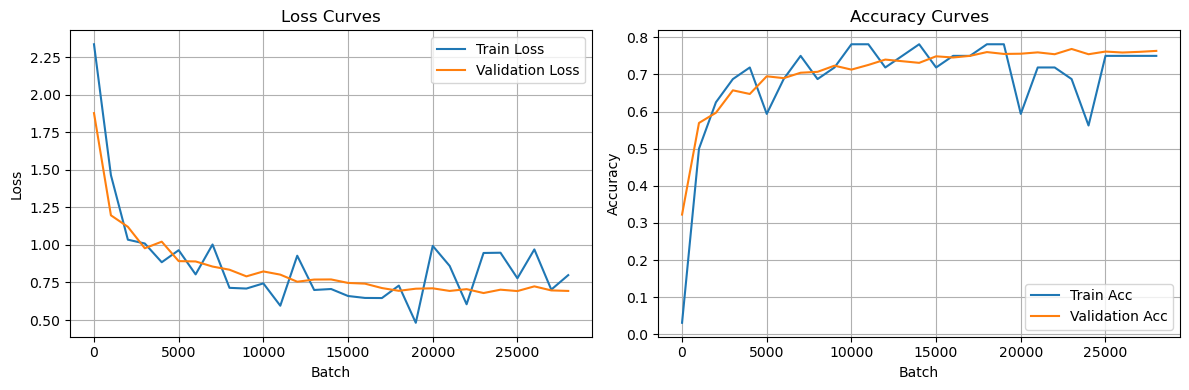

In [13]:
trainer.plot_curves()